In [1]:
import numpy as np
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


This notebook, **py-mcr_Model_3strains**, extends the two-strain model by including a third subpopulation: plasmid-adapted cells ($B_a$) that have acquired compensatory mutations to mitigate the fitness cost of plasmid carriage. The aim is to explore the long-term dynamics and evolutionary processes driving plasmid stability, adaptation, and competition among the three bacterial subpopulations.

The notebook simulates various antibiotic and resource conditions to assess how compensatory adaptation influences the persistence and dynamics of the plasmid-adapted population. This simulation provides insight into the evolutionary and ecological factors that promote the stability of plasmid-bearing populations in complex environments.


### Load parameters obtained from experimental data

In [2]:
# User-defined parameters
B0 = 1e6 #Initial bacterial density
T = 24 #Duration of experimental season
S0 = 1 #Concentration of limiting resource
d = 0.25 #Transfer dilution rate
#seg_rate = 0.02 #0.002 #Segregation rate
seg_rate = 0.11 #0.002 #Segregation rate
mut_rate = 1e-7 #Mutation rate
extinction_threshold=1 #Extinction threshold
alphas=[1e-12, 1e-11, 1e-12] #Antibiotic degradation rate

conj_rate=1e-12
type_experiment='stability'


In [3]:

# Jing 1 (Bp)
VKm_1=5.1786e-10
rho_1=1.16e+09
kappa_1=0.03156029620783811
color_1='#F3901A'
label_1='J53(pE30)'

# Jing 2 (Ba)
VKm_2=5.816e-10
rho_2=1.1984e+09
kappa_2=0.03664679176878976
color_2='#EC5C57'
label_2='Mutant 2'

# Jing 3 (Ba)
VKm_3=5.9105e-10
rho_3=1.0579e+09
kappa_3=0.032919312679410055
color_3='#EC5C57'
label_3='Mutant 3'

# Jing 4 (Ba)
VKm_4=7.5574e-10
rho_4=1.1695e+09
kappa_4=0.0512215457663949
color_4='#EC5C57'
label_4='Mutant 4'

# Jing 5 (B0)
VKm_5=4.0144e-10
rho_5=1.5229e+09
kappa_5=0.5463149583022993
color_5='#52A8F9'
label_5='Mutant 5'

# Jing 6 (B0)
VKm_6=3.4076e-10
rho_6=1.7883e+09
kappa_6=0.539605764024784
color_6='#52A8F9'
label_6='Mutant 6'

# Jing 7 (B0)
VKm_7=2.008e-10
rho_7=2.1412e+09
kappa_7=0.09926220824636105
color_7='#52A8F9'
label_7='Mutant 7'

# Jing 8 (B0)
VKm_8=5.9898e-10
rho_8=1.2862e+09
kappa_8=0.7057148036391183
color_8='#52A8F9'
label_8='Mutant 8'

# Jing 9 (Bp)
VKm_9=2.4078e-10
rho_9=1.2873e+09
kappa_9=0.03156029620783811
color_9='#F3901A'
label_9='J53(pE30)'

VKm_values_all = [VKm_9, VKm_2, VKm_3, VKm_4, VKm_5, VKm_6, VKm_7, VKm_8]
rho_values_all = [rho_9, rho_2, rho_3, rho_4, rho_5, rho_6, rho_7, rho_8]
color_values_all = [color_9, color_2, color_3, color_4, color_5, color_6, color_7, color_8]
type_values_all = ['Bp', 'Ba', 'Ba', 'Ba', 'B0', 'B0', 'B0', 'B0']
strain_labels_all=[label_9, label_2, label_3, label_4, label_5, label_6, label_7, label_8]
kappa_values_all=[kappa_9, kappa_2, kappa_3, kappa_4, kappa_5, kappa_6, kappa_7, kappa_8]

In [4]:

# B0 (average of Jing 5, 6, 7, 8)
mean_VKm_B0 = np.mean([VKm_5, VKm_6, VKm_7, VKm_8])
mean_rho_B0 = np.mean([rho_5, rho_6, rho_7, rho_8])
mean_kappa_B0 = np.mean([kappa_5, kappa_6, kappa_7, kappa_8])
color_B0 = '#52A8F9'

# Ba (average of Jing 2, 3, 4)
mean_VKm_Ba = np.mean([VKm_2, VKm_3, VKm_4])
mean_rho_Ba = np.mean([rho_2, rho_3, rho_4])
mean_kappa_Ba = np.mean([kappa_2, kappa_3, kappa_4])
color_Ba = '#EC5C57'

# Bp (Jing 1, 9)
mean_VKm_Bp = VKm_9 #np.mean([VKm_1, VKm_9])
mean_rho_Bp = rho_9 #np.mean([rho_1, rho_9])
mean_kappa_Bp = kappa_9 #np.mean([kappa_1, kappa_9])
color_Bp = '#F3901A'

# Append new strains to the lists in the correct order
VKm_values_all.extend([mean_VKm_Bp, mean_VKm_B0, mean_VKm_Ba])
rho_values_all.extend([mean_rho_Bp, mean_rho_B0, mean_rho_Ba])
color_values_all.extend([color_Bp, color_B0, color_Ba])
type_values_all.extend(['Bp', 'B0', 'Ba'])
strain_labels_all.extend(['Mean', 'Mean', 'Mean'])
kappa_values_all.extend([mean_kappa_Bp, mean_kappa_B0, mean_kappa_Ba])

# Print the updated lists
print("VKm_values_all:", VKm_values_all)
print("rho_values_all:", rho_values_all)
print("color_values_all:", color_values_all)
print("type_values_all:", type_values_all)
print("strain_labels_all:", strain_labels_all)
print("kappa_values_all:", kappa_values_all)

VKm_values_all: [2.4078e-10, 5.816e-10, 5.9105e-10, 7.5574e-10, 4.0144e-10, 3.4076e-10, 2.008e-10, 5.9898e-10, 2.4078e-10, 3.85495e-10, 6.427966666666667e-10]
rho_values_all: [1287300000.0, 1198400000.0, 1057900000.0, 1169500000.0, 1522900000.0, 1788300000.0, 2141200000.0, 1286200000.0, 1287300000.0, 1684650000.0, 1141933333.3333333]
color_values_all: ['#F3901A', '#EC5C57', '#EC5C57', '#EC5C57', '#52A8F9', '#52A8F9', '#52A8F9', '#52A8F9', '#F3901A', '#52A8F9', '#EC5C57']
type_values_all: ['Bp', 'Ba', 'Ba', 'Ba', 'B0', 'B0', 'B0', 'B0', 'Bp', 'B0', 'Ba']
strain_labels_all: ['J53(pE30)', 'Mutant 2', 'Mutant 3', 'Mutant 4', 'Mutant 5', 'Mutant 6', 'Mutant 7', 'Mutant 8', 'Mean', 'Mean', 'Mean']
kappa_values_all: [0.03156029620783811, 0.03664679176878976, 0.032919312679410055, 0.0512215457663949, 0.5463149583022993, 0.539605764024784, 0.09926220824636105, 0.7057148036391183, 0.03156029620783811, 0.47272443355314064, 0.04026255007153157]


In [5]:

# Define the strain indexes
strain_indexes_all = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

# Construct the model parameters
model_params_all = {
    'B0': B0, #Initial bacterial density
    'T': T,  # Length of experiment
    'S0': S0,  # Resource concentration
    'd': d, #Transfer dilution rate
    'extinction_threshold': extinction_threshold,
    'strain': [strain_labels_all[i-1] for i in strain_indexes_all],
    'type': [type_values_all[i-1] for i in strain_indexes_all],
    'VKm': [VKm_values_all[i-1] for i in strain_indexes_all],  # Adjusted to 0-based indexing
    'rho': [rho_values_all[i-1] for i in strain_indexes_all],  # Adjusted to 0-based indexing
    'colors': [color_values_all[i-1] for i in strain_indexes_all]  # Adjusted to 0-based indexing
}

## Modelling Plasmid-Driven Antibiotic Resistance

Our goal is to postulate a mathematical model that captures the ecological dynamics of a bacterial population comprised of plasmid-bearing, plasmid-free
 and plasmid adapted strains in a homogeneous environment. The model represents the bacterial population's density at time $t$ as $B(t)$, which competes for a single limiting resource, with concentration denoted with $S(t)$.

## Modelling Bacterial Growth

We consider that growth of each bacterial strain is dictated by several key parameters: the maximum uptake rate ($V_{\text{max}}$), the half-saturation constant ($K_m$), and a resource conversion coefficient ($\rho$). These parameters define the Monod term, which encapsulates the fundamental growth kinetics of bacterial strains[ref].

The uptake function $\mathit{U}(S)$, represented by the equation
$$\mathit{U}(S) = \frac{{V_{\text{max}} \cdot S}}{{S + K_m}},$$

determines how the population consumes the limiting resource. The half-saturation constant $K_m$ signifies the resource concentration at which the uptake rate is half of its maximum, hence providing a measure of the affinity of the bacteria for the resource. A low $K_m$ implies a high affinity, meaning the bacteria can utilize the resource effectively even at low concentrations.

Previous studies have established that it is challenging to simultaneously identify the parameters $V_{\text{max}}$ and $K_m$. With our aim being to calibrate these parameters using experimental data, we will use the $V_{\text{max}}/K_m$ ratio, commonly known as the 'specific affinity'. This ratio represents the ability of a strain to sequester and metabolize the resource relative to its saturation level. Importantly, the 'specific affinity' has been demonstrated to be structurally identifiable.

The other parameter relevant for the growth dynamics is the conversion coefficient $\rho$, which represents the efficiency with which cells convert the consumed resources into new biomass, determining the bacterial population's growth rate per unit of resource consumed.
The growth function can thus be expressed as $G(S; \psi)=\rho \cdot U(S)$, with $\psi=(\rho, V_{\text{max}}/K_m)$ representing a vector of parameters that characterize the growth dynamics of a particular bacterial strain.

The Python function uS(S, VKm) approximates the uptake function $\mathit{U}(S)$ described above.

In [6]:

# This function calculates the uptake rate u based on the resource concentration S
# and the Michaelis-Menten constant VKm.
def uS(S, VKm):
    return (S * VKm) / (1 + S)
    #return (S * VKm) / (S + 1/VKm)

## Modeling the Dynamics of Plasmid-bearing, Plasmid-free and Plasmid-adapted Bacterial Populations


Plasmids replicate independently of the bacterial chromosome and therefore a bacterial population may be divided into two distinct subpopulations: plasmid-bearing cells ($B_p$)and plasmid-free cells ($B_\emptyset$). Moreover, we consider a third bacterial subpopulation accounting for plasmid-adapted cells ($B_a$), which have undergone a compensatory mutation process.

The presence or absence of plasmids within these subpopulations can significantly impact their overall behavior and response to environmental stressors, such as antibiotics.

In our model, we assign $B_p$, $B_\emptyset$ and $B_a$ fixed, but distinct, growth kinetic parameters. Adjusting these parameters allows our model to emulate a range of fitness effects associated with plasmid-bearing, from costs to benefits. It's worth mentioning that while fitness costs can be compensated over time, we consider them constant in our model. This simplification is justified as our study is primarily focused on the ecological dynamics, replicating short-term experiments, and less on the evolutionary aspect. Detailed investigation of evolutionary dynamics of the plasmid-host association itself is beyond the scope of this paper and could be an avenue for future research.

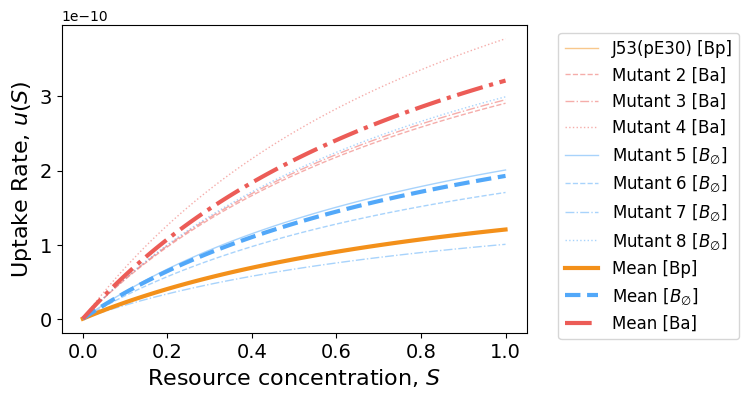

In [7]:
def plot_uptake(S_values, model_params):
    """
    Plot the uptake rates of multiple bacterial strains as a function of resource concentration.

    Parameters
    ----------
    S_values : array-like
        Array of resource concentration values.

    model_params : dict
        Dictionary containing the VKm values, strain labels, and colors.

    Returns
    -------
    None

    Notes
    -----
    This function assumes the existence of a function `uS(S, VKm)`, which calculates the uptake rate
    for a given resource concentration `S` and half-saturation constant `VKm`.
    """
    VKm_values = model_params['VKm']
    strain_labels = ["%s [%s]" % (strain, type_) for strain, type_ in zip(model_params['strain'], model_params['type'])]
    strain_labels = [label.replace('B0', r'$B_{\emptyset}$') for label in strain_labels]

    colors = model_params['colors']

    if len(VKm_values) != len(strain_labels) or len(VKm_values) != len(colors):
        print("The length of VKm_values, strain_labels, and colors must be the same.")
        return

    line_styles = ['-', '--', '-.', ':']

    plt.figure(figsize=(6, 4))

    for i, (VKm, label, color) in enumerate(zip(VKm_values, strain_labels, colors)):
        growth_rates = [uS(S, VKm) for S in S_values]
        if 'Mutant' in label or 'J53' in label:
            plt.plot(S_values, growth_rates, line_styles[i % len(line_styles)], alpha=0.5, linewidth=1, color=color, label=label)
        else:
            plt.plot(S_values, growth_rates, line_styles[i % len(line_styles)], alpha=1, linewidth=3, color=color, label=label)


    plt.xlabel(r'Resource concentration, $S$', fontsize=16)
    plt.ylabel(r'Uptake Rate, $u(S)$', fontsize=16)
    plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tick_params(axis='x', labelsize=14)
    plt.tick_params(axis='y', labelsize=14)
    plt.show()


S_values = np.linspace(0, 1, 100)  # xS values from 0 to 1
plot_uptake(S_values, model_params_all)

## Plasmid segregation

In addition to growth dynamics, our model accounts for the intrinsic processes occurring within plasmid-bearing bacterial cells. One crucial aspect is the segregational loss of plasmids, a random event that occurs during bacterial cell division. As a plasmid-bearing cell divides, it distributes its plasmids to its two offspring cells. Given the probabilistic nature of this distribution, there are instances when one of the offspring cells may not inherit a plasmid, thereby converting it into a plasmid-free cell. This stochastic event, denoted as 'segregational loss', represents an essential dynamic contributing to the overall plasmid count within the bacterial population and can lead to the reduction of plasmid-bearing cells in the absence of positive selection for plasmid-encoded genes. The rate at which this loss occurs is captured by a parameter $\lambda$.

The rate of segregational loss can depend on various factors. If plasmids were to segregate randomly upon division, we could model the segregational loss rate as a function of the plasmid copy number (PCN) in the cell. However, the plasmid we study in our model, pOXA-48, features an active partitioning system. This system aids a more balanced plasmid distribution among daughter cells during division, thus reducing the segregation loss rate. Plasmids with such a system typically have segregation loss rates between $0.1\%$ and $0.2\%$.

In [8]:
model_params_all['seg_rate'] = [seg_rate if t in ['Bp', 'Ba'] else np.NaN for t in model_params_all['type']]

def dB_seg_P(B_TC, seg_rate, uSi_TC):
    """
    Calculate the segregational loss rate of the plasmid-bearing population.

    Parameters
    ----------
    B_TC : float
        The density of the plasmid-bearing population.

    seg_rate : float
        The segregation rate of the plasmid. If NaN, it is assumed to be zero.

    uSi_TC : float
        The specific uptake rate of the limiting resource by the plasmid-bearing population.

    Returns
    -------
    float
        The segregational loss rate of the plasmid-bearing population.

    """
    if np.isnan(seg_rate):
        seg_rate = 0
    return seg_rate * uSi_TC * B_TC

def dB_seg_A(B_A, seg_rate, uSi_A):
    """
    Calculate the segregational loss rate of the plasmid-adapted population.

    Parameters
    ----------
    B_A : float
        The density of the plasmid-adapted population.

    seg_rate : float
        The segregation rate of the plasmid. If NaN, it is assumed to be zero.

    uSi_A : float
        The specific uptake rate of the limiting resource by the plasmid-adapted population.

    Returns
    -------
    float
        The segregational loss rate of the plasmid-adapted population.

    """
    if np.isnan(seg_rate):
        seg_rate = 0
    return seg_rate * uSi_A * B_A


## Plasmid conjugation

The model incorporates the horizontal transfer of plasmids between cells via conjugation. We model the net change in the plasmid-bearing bacterial population due to conjugation events, taking into account the densities of plasmid-free ($B_{\emptyset}$), plasmid-bearing ($B_p$) and plasmid-adapted ($B_a$) populations. In our well-mixed environment, we assume the principle of mass action, which in this context means that the probability of two cells encountering each other and engaging in conjugation is proportional to the densities of both the plasmid-free and plasmid-bearing and adapted subpopulations.

In our model, we incorporate the rate of plasmid transfer, measured in conjugation events per donor cell per hour, by introducing a parameter that quantifies the propensity of a bacterial cell to accept a plasmid from another cell. This introduces a parameter, 'permissiveness' that we denote with $\gamma$, to measure a bacterial cell's propensity to accept a plasmid from another cell.

In [9]:
model_params_all['conj_rate'] = [conj_rate if t in ['Bp', 'Ba'] else np.NaN for t in model_params_all['type']]


def dB_conj_single(B_WT, B_TC, conj_rate):
    """
    Calculate the conjugation rate of a single strain, i.e., the rate at which the plasmid is transferred from
    the plasmid-bearing population (TransConjugant) to the plasmid-free population (WildType).

    Parameters
    ----------
    B_WT : float
        The density of the plasmid-free population (WildType).

    B_TC : float
        The density of the plasmid-bearing population (TransConjugant).

    conj_rate : float
        The conjugation rate of the plasmid. If NaN, it is assumed to be zero.

    Returns
    -------
    float
        The conjugation rate for a single strain.

    """
    if np.isnan(conj_rate): # Below detectable limits
        conj_rate = 0
    ret = conj_rate * B_WT * B_TC
    return ret

def dB_conj_single_A(B_WT, B_A, conj_rate):
    """
    Calculate the conjugation rate of a single strain, i.e., the rate at which the plasmid is transferred from
    the plasmid-bearing population (TransConjugant) to the plasmid-free population (WildType).

    Parameters
    ----------
    B_WT : float
        The density of the plasmid-free population (WildType).

    B_TC : float
        The density of the plasmid-bearing population (TransConjugant).

    conj_rate : float
        The conjugation rate of the plasmid. If NaN, it is assumed to be zero.

    Returns
    -------
    float
        The conjugation rate for a single strain.

    """
    if np.isnan(conj_rate): # Below detectable limits
        conj_rate = 0
    ret = conj_rate * B_WT * B_A
    return ret

## Compensatory mutations

The acquisition of plasmid usually imposes significant metabolic costs upon host cells. However, compensatory mutations occurring on plasmids can reduce the fitness costs of plasmid carriage, allowing the stabilization of plasmids in a bacterial population. Furthermore, this amelioration of the fitness cost may increase plasmid persistence even in environments without positive selection for plasmid traits and increase the risk of plasmid-encoded antibiotic resistance.

Considering compensatory mutations located on the chromosome, the subpopulation of adapted plasmid-bearers $B_a$ is proportional to fission with $\chi G(R;\psi_p)\cdot B_p$ with plasmids costs reduced by $\psi_p$. The subpopulation of adapted plasmid bearers $B_a$ also benefits from the conjugation by $\gamma B_\emptyset B_a$, since $B_a$ can't transmit the chromosomal mutation by conjugation.

In [10]:
model_params_all['mut_rate'] = [mut_rate if t == 'Bp' else np.NaN for t in model_params_all['type']]


def dB_mut(B_TC, mut_rate):
    """
    Calculate the mutation rate of a single strain,

    Parameters
    ----------
    B_TC : float
        The density of the plasmid-bearing population (TransConjugant).

    mut_rate : float
        The mutation rate of the plasmid. If NaN, it is assumed to be zero.

    Returns
    -------
    float
        The mutation rate for a single strain.

    """
    if np.isnan(conj_rate): # Below detectable limits
        mut_rate = 0
    ret = mut_rate * B_TC
    return ret



## Modelling susceptibility to bactericidal antibiotics

Our model incorporates the impact of antibiotic resistance on bacterial populations. Specifically, it represents the antibiotic concentration at any given time $t$ as $A(t)$. We are dealing with bactericidal antibiotics, such as beta-lactam antibiotics, that are subject to enzymatic degradation. The model includes an inactivation rate for antibiotic molecules, which is assumed to be proportional to the total bacterial population and the environmental antibiotic concentration. We consider the rate of degradation to be higher for plasmid-bearing cells, $\alpha_p > \alpha_{\emptyset} \geq 0$, and $\alpha_p = \alpha_a$.

The antibiotic-induced death rate in the model is governed by the antibiotic concentration at any given time, the size of the bacterial subpopulation, and the product of the antibiotic concentration and a strain's resistance coefficient, $\kappa$. In this context, $\kappa$ is a measure of the bacterial strain's inherent susceptibility to the antibiotic - a larger $\kappa$ implies greater susceptibility.

The death rate of bacterial cells due to the antibiotic is calculated using the following function:


In [11]:
model_params_all['kappa'] = [kappa_values_all[i-1] for i in strain_indexes_all]  # Adjusted to 0-based indexing
model_params_all['alphas']=np.array(alphas)  #Antibiotic degradation rate


def dB_kill(A, Bs, kappa):
    """
    Calculate the death rate of bacterial cells due to an antibiotic.

    Parameters
    ----------
    A : float
        The concentration of the antibiotic.

    Bs : float
        The density of the bacterial population.

    kappa : float
        A parameter that scales the kill rate in relation to the antibiotic concentration.

    Returns
    -------
    float
        The death rate of bacterial cells due to the antibiotic.
    """
    kill_rate = kappa * A
    return kill_rate * Bs


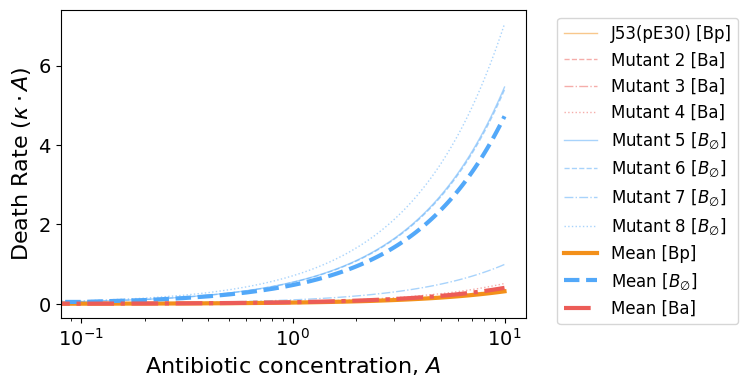

In [12]:
def plot_death_rate(A_values, model_params):
    """
    Plot the death rates of multiple bacterial strains as a function of antibiotic concentration.

    Parameters
    ----------
    A_values : array-like
        Array of antibiotic concentration values.

    model_params : dict
        Dictionary containing the kappa values, strain labels, and colors.

    Returns
    -------
    None

    Notes
    -----
    This function calculates the death rate as kappa * A * MIC_max.
    """
    kappa_values = model_params['kappa']

    strain_labels = ["%s [%s]" % (strain, type_) for strain, type_ in zip(model_params['strain'], model_params['type'])]
    strain_labels = [label.replace('B0', r'$B_{\emptyset}$') for label in strain_labels]


    colors = model_params['colors']

    if len(kappa_values) != len(strain_labels) or len(kappa_values) != len(colors):
        print("The length of kappa_values, strain_labels, and colors must be the same.")
        return

    line_styles = ['-', '--', '-.', ':']

    plt.figure(figsize=(6, 4))

    for i, (kappa, label, color) in enumerate(zip(kappa_values, strain_labels, colors)):
        death_rates = [kappa * A for A in A_values]

        if 'Mutant' in label or 'J53' in label:
            plt.plot(A_values, death_rates, line_styles[i % len(line_styles)], alpha=0.5, linewidth=1, color=color, label=label)
        else:
            plt.plot(A_values, death_rates, line_styles[i % len(line_styles)], alpha=1, linewidth=3, color=color, label=label)

    plt.xlabel(r'Antibiotic concentration, $A$', fontsize=16)
    plt.ylabel(r'Death Rate ($\kappa \cdot A$)', fontsize=16)
    plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tick_params(axis='x', labelsize=14)
    plt.tick_params(axis='y', labelsize=14)
    plt.xscale('log')  # To plot x-axis in log scale
    plt.show()



# Plot the death rates
A_values = np.linspace(0, 10, 100)
plot_death_rate(A_values, model_params_all)

## Model parameters

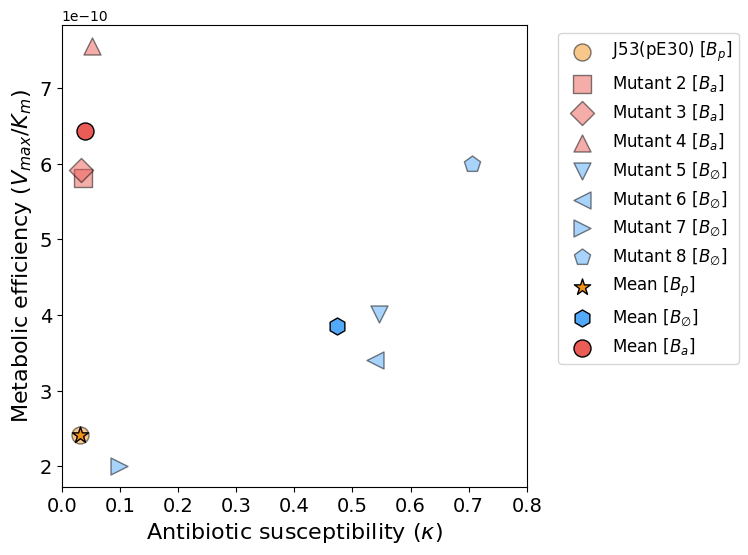

In [39]:
def plot_scatter_vkm_kappa(model_params):
    """
    Plot the scatter distribution of VKm (Michaelis-Menten constants) and kappa (drug resistance coefficients).

    Parameters
    ----------
    model_params : dict
        Dictionary of model parameters.
    """
    VKm = model_params.get('VKm', [])
    kappa = model_params.get('kappa', [])

    strain_labels = ["%s [%s]" % (strain, type_) for strain, type_ in zip(model_params['strain'], model_params['type'])]
    strain_labels = [label.replace('B0', r'$B_{\emptyset}$') for label in strain_labels]
    strain_labels = [label.replace('Ba', r'$B_{a}$') for label in strain_labels]
    strain_labels = [label.replace('Bp', r'$B_{p}$') for label in strain_labels]


    facecolors = model_params['colors']

    if len(VKm) != len(kappa) or len(VKm) != len(strain_labels):
        print("The length of VKm, kappa, and strain_labels must be the same.")
        return

    colors = ['orange', 'blue', 'red', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h']

    plt.figure(figsize=(6, 6))

    for i, (v, k) in enumerate(zip(VKm, kappa)):

        if 'Mutant' in strain_labels[i] or 'J53' in strain_labels[i]:
            plt.scatter(k, v, color=colors[i % len(colors)], edgecolors='black', facecolors=facecolors[i], marker=markers[i % len(markers)], s=150, alpha=0.5, label=strain_labels[i])
        else:
            plt.scatter(k, v, color=colors[i % len(colors)], edgecolors='black', facecolors=facecolors[i], marker=markers[i % len(markers)], s=150, alpha=1, label=strain_labels[i])

    #for i, (v, k) in enumerate(zip(VKm, kappa)):
    #    plt.annotate(strain_labels[i], (k, v), textcoords="offset points", xytext=(12, -12), ha='center')

    plt.ylabel(r'Metabolic efficiency ($V_{max}/K_m$)', fontsize=16)
    plt.xlabel(r'Antibiotic susceptibility ($\kappa$)', fontsize=16)
    plt.grid(False)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlim([0, 0.8])
    plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()



plot_scatter_vkm_kappa(model_params_all)

## Plasmid population dynamics model

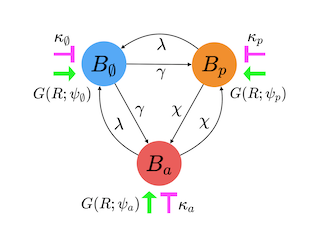

Altogether, our model captures the dynamics of a bacterial population composed of 3 distinct subpopulations: plasmid-bearing ($B_p$), plasmid-free ($B_\emptyset$) and plasmid-adapted ($B_a$)cells. All subpopulations compete for a limiting resource, $S$, and are susceptible to an antibiotic, $A$. The interplay between vertical and horizontal plasmid transmission routes via segregational loss and conjugation, respectively, plays a significant role in shaping the plasmid distribution and persistence within these subpopulations over time.

We describe the system through a set of differential equations, which encapsulate the temporal evolution of the system state $\bar{x}=(R, A, B_\emptyset, B_p, B_a)$, and that can be written as:

\begin{align}
\frac{dR}{dt}&=-\left(\mathit{U}(R; \psi_\emptyset) \cdot B_\emptyset + \mathit{U}(R; \psi_p) \cdot B_p +\mathit{U}(R; \psi_a) \cdot B_a\right),\\
\frac{dA}{dt}&=-A\cdot (\alpha_\emptyset B_\emptyset + \alpha_p B_p+ \alpha_a B_a),\\
\frac{dB_\emptyset}{dt}&= \left(G(R; \psi_\emptyset) - \kappa_\emptyset A \right) \cdot B_\emptyset + \lambda\left( G(R; \psi_p)\cdot B_p + G(R; \psi_a)\cdot B_a\right) - \gamma \,( B_\emptyset \, B_p +B_\emptyset \, B_a),\\
\frac{dB_p}{dt}&= \left(1 - \lambda  \right) G(R; \psi_p) \cdot B_p - \kappa_p A\cdot B_p + \gamma ( B_\emptyset \, B_p+B_\emptyset \, B_a)-\chi G(R; \psi_p)\cdot B_p,\\
\frac{dB_a}{dt}&= (1-\lambda) G(R; \psi_a)\cdot B_a -\kappa_a A\cdot B_a+\chi G(R; \psi_p)\cdot B_p,
\end{align}

The initial conditions are determined by the starting resource concentration, which is set to $R_0=1$ throughout our study, and the environmental drug concentration, denoted as $A \geq 0$. The initial densities of $B_a(0)$, $B_p(0)$ and $B_\emptyset (0)$ are given by the specific experimental setup being simulated. In particular, we simulate a plasmid invasion experiment, whereby the majority of the population consists of $B_\emptyset$ cells and a minor fraction (in our simulations we consider that 0.01\%) is plasmid-bearing, $B_p$ and $B_a$.




In [14]:

def f3strains(t, y, params):
    """
    This function implements a set of ordinary differential equations describing the population dynamics of
    plasmid-bearing (TC), plasmid-free (WT) and plasmid-dapted (A) cells competing for a limiting resource and exposed to a
    bactericidal antibiotic.

    State variables are Resource (S) and Antibiotic (A) concentrations, and Densities of Plasmid-bearing (B_TC)
    , Plasmid-free (B_WT) and Plasmid-adapted (B_A) bacteria.

    Parameters
    ----------
    t : float
        Time variable for the ODE solver.

    y : array
        Array of initial values of the state variables, [S, A, B_TC, B_WT, B_A].

    params : dict
        A dictionary of model parameters including 'VKm', 'rho', 'seg_rate', 'kappa', 'MIC_max', 'conj_rate',
        and 'alphas'.

    Returns
    -------
    array
        Array of the derivatives of the state variables.
    """
    S = y[0]
    A = y[1]
    B_TC = y[2]
    B_WT = y[3]
    B_A = y[4]

    # For plasmid-adapted (A)
    uSi_A = uS(S, params['VKm'][2])
    uStot_A = uSi_A * B_A

    dB_A_growth = params['rho'][2] * uSi_A * B_A
    dB_A_seg = dB_seg_A(B_A, params['seg_rate'][2], uSi_A)

    db_MIC_A = params['kappa'][2]
    dB_A_kill = dB_kill(A, B_A, db_MIC_A)

    conj_permissiveness = params['conj_rate'][0] # permissiveness of WT
    dB_A_conj =  conj_permissiveness * B_WT * B_A #dB_conj_single_A(B_WT, B_A, conj_permissiveness)

    mutation_rate = params['mut_rate'][0]
    dB_A_mut = dB_mut(B_TC, mutation_rate)

    #dB_A_mut_conj = dB_conj_mut(B_WT, B_A, conj_permissiveness, mutation_rate )

    dB_A = dB_A_growth - dB_A_seg - dB_A_kill + dB_A_mut + dB_A_conj

    #####
    # For plasmid-bearing (TC)
    uSi_TC = uS(S, params['VKm'][0])
    uStot_TC = uSi_TC * B_TC

    dB_TC_growth = params['rho'][0] * uSi_TC * B_TC
    dB_TC_seg = dB_seg_P(B_TC, params['seg_rate'][0], uSi_TC)

    db_MIC_TC = params['kappa'][0]
    dB_TC_kill = dB_kill(A, B_TC, db_MIC_TC)

    conj_permissiveness = params['conj_rate'][0] # permissiveness of WT
    dB_TC_conj = conj_permissiveness * B_WT * B_TC #0 #dB_conj_single(B_WT, B_TC, conj_permissiveness)

    #####
    dB_TC = dB_TC_growth + dB_TC_conj - dB_TC_seg - dB_TC_kill - dB_A_mut

    # For plasmid-free (WT)
    uSi_WT = uS(S, params['VKm'][1])
    uStot_WT = uSi_WT * B_WT

    dB_WT_growth = params['rho'][1] * uSi_WT * B_WT

    db_MIC_WT = params['kappa'][1]
    dB_WT_kill = dB_kill(A, B_WT, db_MIC_WT)

    #dB_WT_seg= params['rho'][1] * uSi_TC * B_TC * params['seg_rate'][0]
    #dB_WT_seg= dB_seg_P(B_TC, params['seg_rate'][0], uSi_TC)

    #conj_permissiveness = params['conj_rate'][0] # permissiveness of WT
    #dB_WT_conj = dB_conj_single(B_WT, B_TC, conj_permissiveness)
    #dB_WT_conj_A=dB_conj_single_A(B_WT, B_A, conj_permissiveness)


    #####
    dB_WT = dB_WT_growth - dB_TC_conj - dB_A_conj - dB_WT_kill + dB_TC_seg + dB_A_seg


    #####
    dS =  - (uStot_TC + uStot_WT + uStot_A)

    #####
    dA = -A * (params['alphas'][0] * B_TC + params['alphas'][1] * B_WT + params['alphas'][0] * B_A)

    return np.array([dS, dA, dB_TC, dB_WT, dB_A])

In [15]:

def simulate_model(model_params, y0):
    """
    The function runs the simulation of our model by solving the system of ordinary differential equations (ODEs).
    It uses the solve_ivp method from the SciPy library with backward differentiation, returning the time points
    and corresponding solution vectors.

    Parameters
    ----------
    model_params : dict
        A dictionary of model parameters including 'T' for time span, 'VKm', 'rho', 'seg_rate', 'kappa', 'MIC_max',
        'conj_rate', and 'alphas'.

    y0 : array
        Array of initial conditions for the state variables [S, A, B_TC, B_WT, B_A].

    Returns
    -------
    tuple
        times : array
            The time points at which the solution was evaluated.

        ys : 2D array
            The corresponding solution vectors for each time point.
    """

    t_span = [0, model_params['T']]

    # Solve the ODE
    sol = solve_ivp(f3strains, t_span, y0, args=(model_params,), method='BDF', max_step=0.1, rtol=1e-5, atol=1e-8)

    # Extract the time points and solution vectors
    times = sol.t
    ys = sol.y

    return times, ys



In [16]:
def plot_simulation(t, ys):
    """
    Generates three plots to visualize the simulation results.
    The first plot shows the resource and antibiotic concentrations over time;
    the second plot depicts the density of the plasmid-bearing and plasmid-free strains over time;
    the third plot illustrates the relative abundance of each strain over time.

    Parameters
    ----------
    t : array
        The time points at which the solution was evaluated.
    ys : 2D array
        The corresponding solution vectors for each time point.

    Returns
    -------
    None
    """
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    S = ys[0]
    A = ys[1]
    B_TC = ys[2]
    B_WT = ys[3]
    B_A = ys[4]
    B_total = B_TC + B_WT + B_A

    # Plot bacterial density
    axs[0].plot(t, S, label='Resource', color='lime')
    axs[0].plot(t, A, label='Antibiotic (units of MIC)', color='magenta')
    axs[0].set_xlabel('Time (hours)', fontsize=16)
    axs[0].set_ylabel(r'Concentration ($\mu g/ml$)', fontsize=16)
    axs[0].set_ylim([-0.05, 1.1])
    axs[0].tick_params(axis='x', labelsize=14)
    axs[0].tick_params(axis='y', labelsize=14)

    # Plot plasmid-bearing and plasmid-free strains' density
    axs[1].plot(t, B_TC, '-', label='TC', color='#F3901A')
    axs[1].plot(t, B_WT, '-', label='WT', color='#52A8F9')
    axs[1].plot(t, B_A, '-', label='A', color='#EC5C57')
    axs[1].plot(t, B_total, dashes=[12, 6, 3, 6, 3, 6], label='WT', color='k')
    axs[1].set_xlabel('Time (hours)', fontsize=16)
    axs[1].set_ylabel('Density (log cells/ml)', fontsize=16)
    axs[1].set_yscale('log')
    axs[1].tick_params(axis='x', labelsize=14)
    axs[1].tick_params(axis='y', labelsize=14)

    # Calculate relative abundance of each strain
    rel_B_TC = B_TC / B_total
    rel_B_WT = B_WT / B_total
    rel_B_A = B_A / B_total
    rel_B_TOT = (B_TC + B_WT + B_A) / B_total

    # Plot relative abundance
    axs[2].plot(t, rel_B_TC * 100, '-', label=r'$B_p$', color='#F3901A')
    axs[2].plot(t, rel_B_WT * 100, '-', label=r'$B_\emptyset$', color='#52A8F9')
    axs[2].plot(t, rel_B_A * 100, '-', label=r'$B_a$', color='#EC5C57')
    axs[2].plot(t, rel_B_TOT * 100, dashes=[12, 6, 3, 6, 3, 6], label=r'$B_{total}$', color='k')
    axs[2].set_xlabel('Time (hours)', fontsize=16)
    axs[2].set_ylabel('Frequency (%)', fontsize=16)
    axs[2].tick_params(axis='x', labelsize=14)
    axs[2].tick_params(axis='y', labelsize=14)

    # Add legends
    axs[0].legend(fontsize=12, loc='lower left')
    axs[2].legend(fontsize=12, loc='upper left')

    # Adjust layout for better appearance
    plt.tight_layout()

    plt.show()


# Numerical examples

To illustrate the plasmid population dynamics, we will simulate a drug-free scenario by setting the initial environmental antibiotic concentration, denoted as $A$, to 0. The simulation's initial conditions are defined by the variable $y_0 = (S_0, A, 0, B_0)$, which represents the initial substrate concentration ($S_0$), the environmental antibiotic concentration ($A$), and the initial bacterial density. In this particular example, we assume that all cells in the population are plasmid-free, and their density is denoted as $B_0$.

In [17]:

# Define the strain indexes
strain_indexes = [9, 10, 11]

# Construct the model parameters
model_params = {
    'B0': B0, #Initial bacterial density
    'T': T,  # Length of experiment
    'S0': S0,  # Resource concentration
    'd': d, #Transfer dilution rate
    'extinction_threshold': extinction_threshold,
    'strain': [strain_labels_all[i-1] for i in strain_indexes],
    'type': [type_values_all[i-1] for i in strain_indexes],
    'VKm': [VKm_values_all[i-1] for i in strain_indexes],  # Adjusted to 0-based indexing
    'rho': [rho_values_all[i-1] for i in strain_indexes],  # Adjusted to 0-based indexing
    'colors': [color_values_all[i-1] for i in strain_indexes],  # Adjusted to 0-based indexing
    'kappa': [kappa_values_all[i-1] for i in strain_indexes],  # Adjusted to 0-based indexing
    'mut_rate': [mut_rate if t == 'Bp' else np.NaN for t in ['Bp','B0','Ba']],
    'conj_rate': [conj_rate if t in ['Bp', 'Ba'] else np.NaN for t in ['Bp','B0','Ba']],
    'seg_rate': [seg_rate if t in ['Bp', 'Ba'] else seg_rate for t in ['Bp','B0','Ba']],
    'alphas' : np.array(alphas)  #Antibiotic degradation rate
    }

print(model_params)

{'B0': 1000000.0, 'T': 24, 'S0': 1, 'd': 0.25, 'extinction_threshold': 1, 'strain': ['Mean', 'Mean', 'Mean'], 'type': ['Bp', 'B0', 'Ba'], 'VKm': [2.4078e-10, 3.85495e-10, 6.427966666666667e-10], 'rho': [1287300000.0, 1684650000.0, 1141933333.3333333], 'colors': ['#F3901A', '#52A8F9', '#EC5C57'], 'kappa': [0.03156029620783811, 0.47272443355314064, 0.04026255007153157], 'mut_rate': [1e-07, nan, nan], 'conj_rate': [1e-12, nan, 1e-12], 'seg_rate': [0.11, 0.11, 0.11], 'alphas': array([1.e-12, 1.e-11, 1.e-12])}


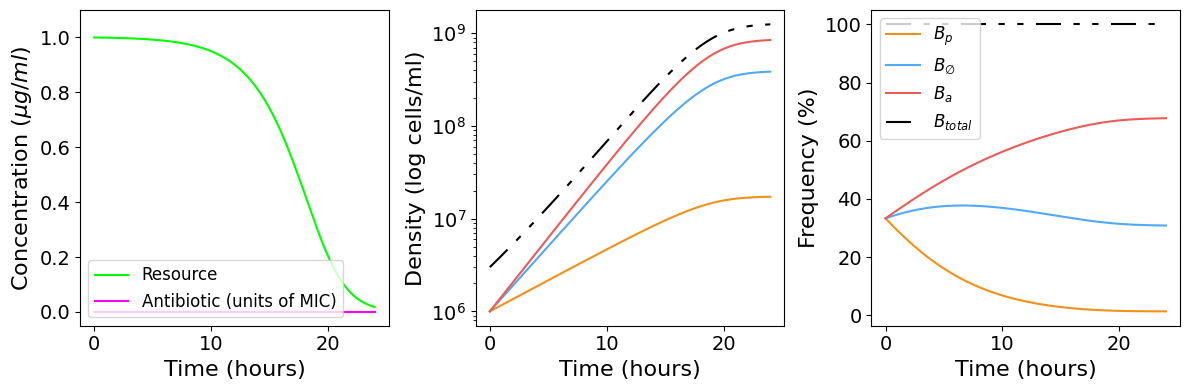

In [18]:
# Run the simulation (drug free, plasmid-bearing)
A=0. #Environmental drug concentration
# y0 : Array of initial conditions for the state variables [S, A, B_TC, B_WT, B_A].
y0 = np.concatenate(([S0],[A], [B0, B0, B0]))
times, ys = simulate_model(model_params, y0)
plot_simulation(times, ys)

In this second example, the environmental antibiotic concentration is set to $A=1$, indicating that the bacterial populations are now subject to antibiotic pressure. Under these conditions, the plasmid-bearing population outperforms the plasmid-free cells due to their enhanced resistance to the antibiotic. The survival advantage of the plasmid-bearing cells is depicted in the resulting plot, showing the role of plasmids by allowing the $B_a$ cells to proliferate when $A>0$.


A=1


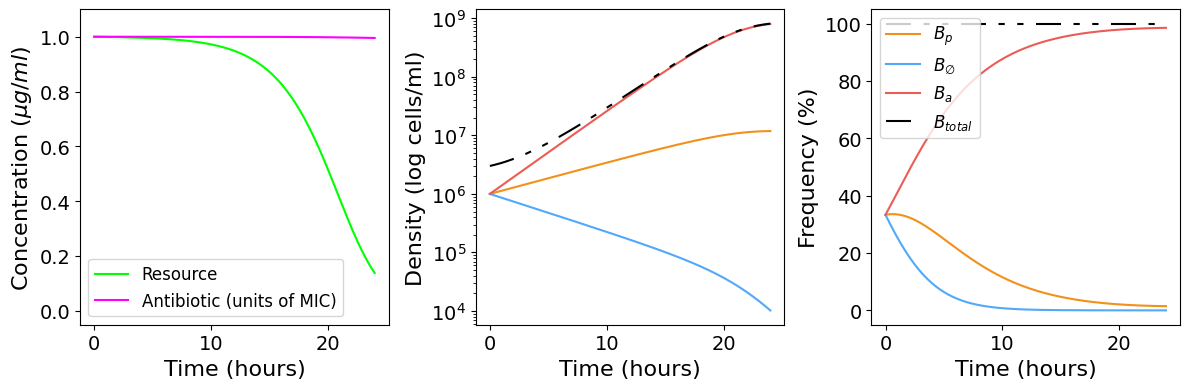

In [19]:
A=1 #Environmental drug concentration
print("A=%s"%A)
y0 = np.concatenate(([S0],[A], [B0, B0, B0]))
times, ys = simulate_model(model_params, y0)
plot_simulation(times, ys)

In contrast, performing a similar numerical experiment with plasmid-free cells highlights that the antibiotic leads to the eradication of the entire $B_{\emptyset}$ population.

A=1


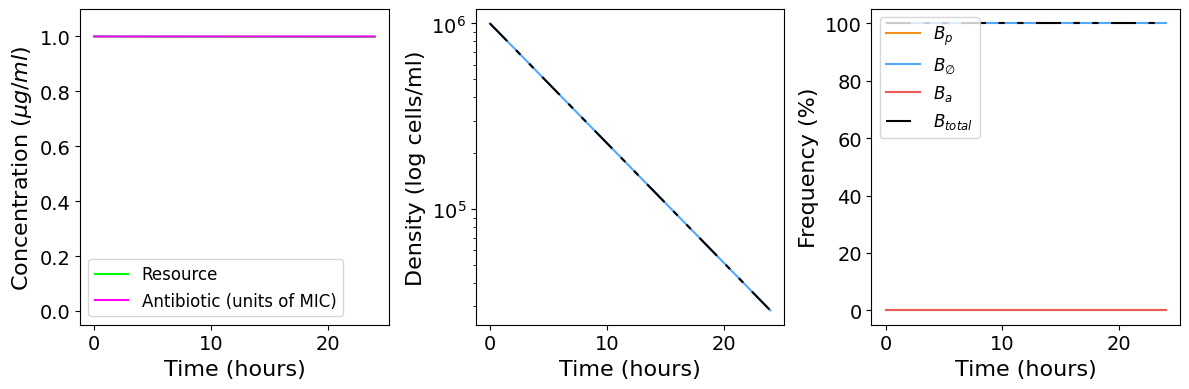

In [20]:
# Run the simulation
A=1 #Environmental drug concentration
print("A=%s"%A)
y0 = np.concatenate(([S0],[A], [0, B0, 0]))
times, ys = simulate_model(model_params, y0)
plot_simulation(times, ys)

Serial Dilution

In [21]:
def simulateTransfers_fmutantstrain(model_params, E, type_experiment='stability', verbose=False):
    """
    Simulate serial dilutions for multiple days using the fmutantstrain function.

    Parameters
    ----------
    model_params : dict
        Dictionary of model parameters.
    E : array-like
        Array of antibiotic concentrations for each day.
    type_experiment : str, optional
        Type of experiment ('stability', 'competition', 'invasion'). Default is 'stability'.
    verbose : bool, optional
        If True, print debug information. Default is False.

    Returns
    -------
    times_list : list of arrays
        List of time points for each day.
    ys_list : list of 2D arrays
        List of solution vectors for each day.
    """
    times_list = []
    ys_list = []

    S0 = model_params['S0']
    B0 = model_params['B0']
    d = model_params['d']
    num_strains = 3  # Number of strains: B_p, B_0, B_a

    for day in range(len(E)):
        A = E[day]

        if day == 0:
            if type_experiment == 'stability':
                B_initial = np.zeros(num_strains)
                B_initial[0] = B0  # Assuming B_p is the initial strain
                B_initial[1] = 0  # Assuming B_0 is the initial strain
                B_initial[2] = 0  # Assuming B_a is the initial strain
                yi = np.concatenate(([S0], [A], B_initial))

            elif type_experiment == 'competition':
                yi = np.concatenate(([S0], [A], B0 * np.ones(num_strains) / num_strains))

            if verbose:
                print(f"Initial conditions for day 0: {yi}")

            times, ys = simulate_model(model_params, yi)

        else:
            yi = ys[:, -1] * d
            yi[0] = S0
            yi[1] = A

            if verbose:
                print(".", end="")

            times, ys = simulate_model(model_params, yi)

        times_list.append(times)
        ys_list.append(ys)

    return times_list, ys_list

def simulate_model(model_params, y0):
    """
    Run the simulation of our model by solving the system of ODEs.

    Parameters
    ----------
    model_params : dict
        Dictionary of model parameters.
    y0 : array
        Initial conditions for the state variables [R, A, B_p, B_0, B_a].

    Returns
    -------
    tuple
        times : array
            The time points at which the solution was evaluated.
        ys : 2D array
            The corresponding solution vectors for each time point.
    """
    t_span = [0, model_params['T']]

    # Solve the ODE
    sol = solve_ivp(f3strains, t_span, y0, args=(model_params,), method='BDF', max_step=0.1, rtol=1e-5, atol=1e-8)

    # Extract the time points and solution vectors
    times = sol.t
    ys = sol.y

    return times, ys


Initial conditions for day 0: [1.e+00 0.e+00 1.e+06 0.e+00 0.e+00]
...Day 0:


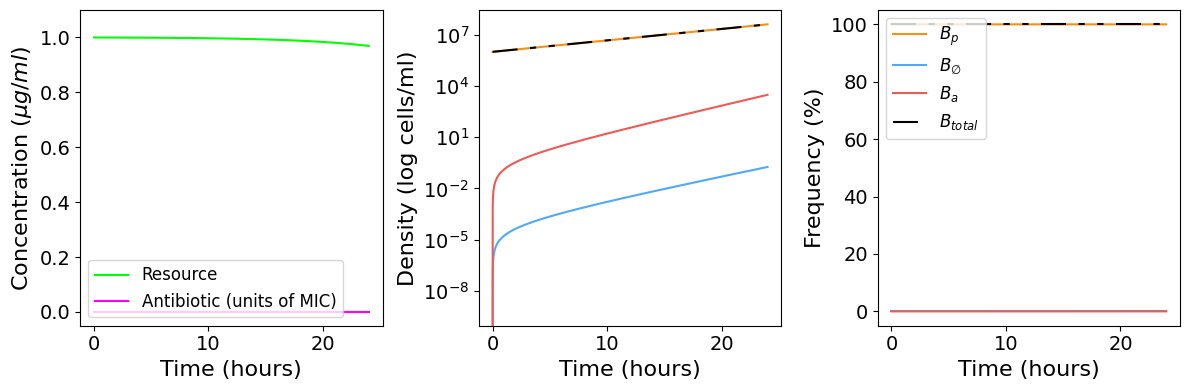

Day 1:


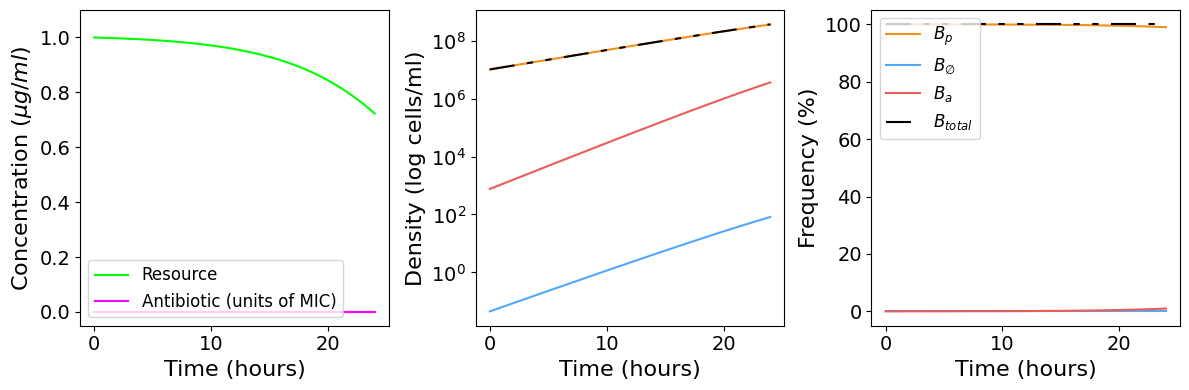

Day 2:


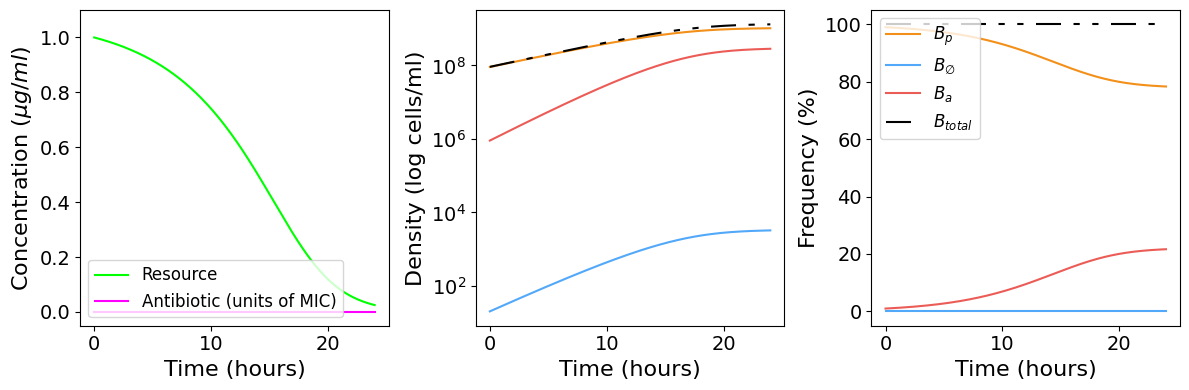

Day 3:


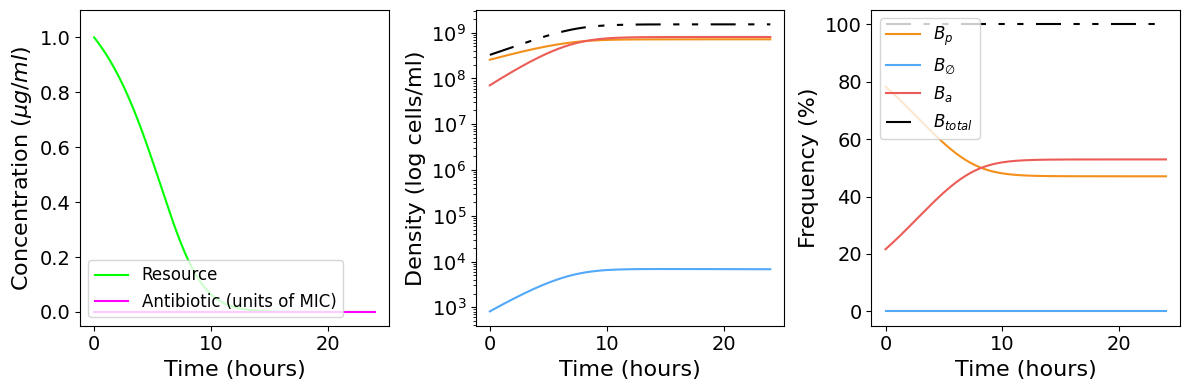

In [22]:
# Example antibiotic concentrations for each day
E = [0., 0., 0., 0.]

# Run the simulation
times_list, ys_list = simulateTransfers_fmutantstrain(model_params, E, type_experiment='stability', verbose=True)

# Plot the results
for i, (times, ys) in enumerate(zip(times_list, ys_list)):
    print(f"Day {i}:")
    plot_simulation(times, ys)

In [23]:
def runEvolutionaryExperiment(model_params, E, type_experiment='stability', verbose=False):
    """
    Run the evolutionary experiment, simulating serial dilutions and plotting the results.

    Parameters
    ----------
    model_params : dict
        Dictionary of model parameters.
    E : array-like
        Array of antibiotic concentrations for each day.
    type_experiment : str, optional
        Type of experiment ('stability', 'competition', 'invasion'). Default is 'stability'.
    verbose : bool, optional
        If True, print debug information. Default is False.

    Returns
    -------
    result : list of tuples
        List containing time points and solution vectors for each day.
    """
    # Run the simulation
    times_list, ys_list = simulateTransfers_fmutantstrain(model_params, E, type_experiment, verbose)

    # Combine the results into a list of tuples
    result = list(zip(times_list, ys_list))

    return result

In [24]:
def display_params(model_params):
    """
    Display the model parameters in a human-readable form.

    Parameters
    ----------
    model_params : dict
        Dictionary of model parameters.
    """
    descriptions = {
        'B0': 'Initial bacterial density',
        'T': 'Duration of experimental season (hours)',
        'S0': 'Initial concentration of limiting resource',
        'd': 'Transfer dilution rate',
        'extinction_threshold': 'Extinction threshold',
        'VKm': 'Michaelis-Menten constants',
        'rho': 'Maximum growth rates',
        'seg_rate': 'Segregation rates',
        'kappa': 'Drug resistance coefficients',
        'MIC_max': 'Maximum inhibitory concentration',
        'conj_rate': 'Conjugation rates',
        'mut_rate': 'Mutation rates',
        'alphas': 'Antibiotic degradation rates',
    }

    print("Model Parameters:")
    for key, value in model_params.items():
        description = descriptions.get(key, 'No description available')
        print(f"{key} ({description}): {value}")

display_params(model_params)

Model Parameters:
B0 (Initial bacterial density): 1000000.0
T (Duration of experimental season (hours)): 24
S0 (Initial concentration of limiting resource): 1
d (Transfer dilution rate): 0.25
extinction_threshold (Extinction threshold): 1
strain (No description available): ['Mean', 'Mean', 'Mean']
type (No description available): ['Bp', 'B0', 'Ba']
VKm (Michaelis-Menten constants): [2.4078e-10, 3.85495e-10, 6.427966666666667e-10]
rho (Maximum growth rates): [1287300000.0, 1684650000.0, 1141933333.3333333]
colors (No description available): ['#F3901A', '#52A8F9', '#EC5C57']
kappa (Drug resistance coefficients): [0.03156029620783811, 0.47272443355314064, 0.04026255007153157]
mut_rate (Mutation rates): [1e-07, nan, nan]
conj_rate (Conjugation rates): [1e-12, nan, 1e-12]
seg_rate (Segregation rates): [0.11, 0.11, 0.11]
alphas (Antibiotic degradation rates): [1.e-12 1.e-11 1.e-12]


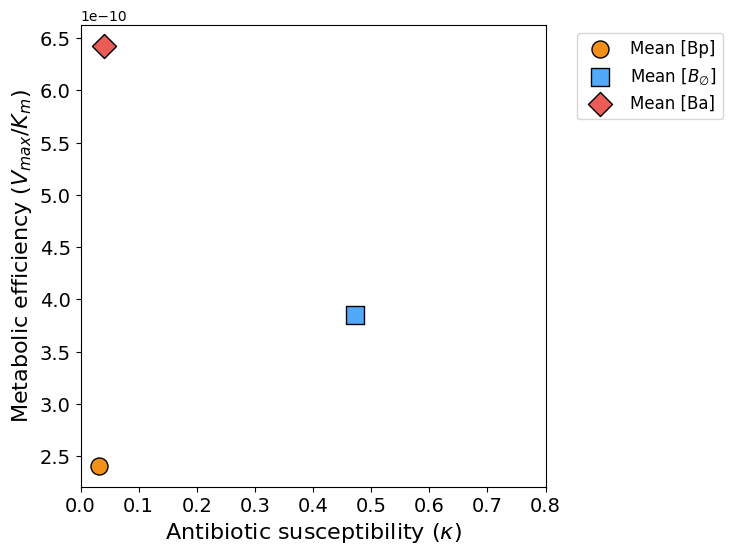

In [25]:

plot_scatter_vkm_kappa(model_params)

In [26]:
Amax=0.0
num_days=51


E = Amax*np.zeros(num_days)

y0 = np.array([S0, Amax, B0 , 0, 0])
result = runEvolutionaryExperiment(model_params, E, type_experiment, verbose=True)


Initial conditions for day 0: [1.e+00 0.e+00 1.e+06 0.e+00 0.e+00]
..................................................

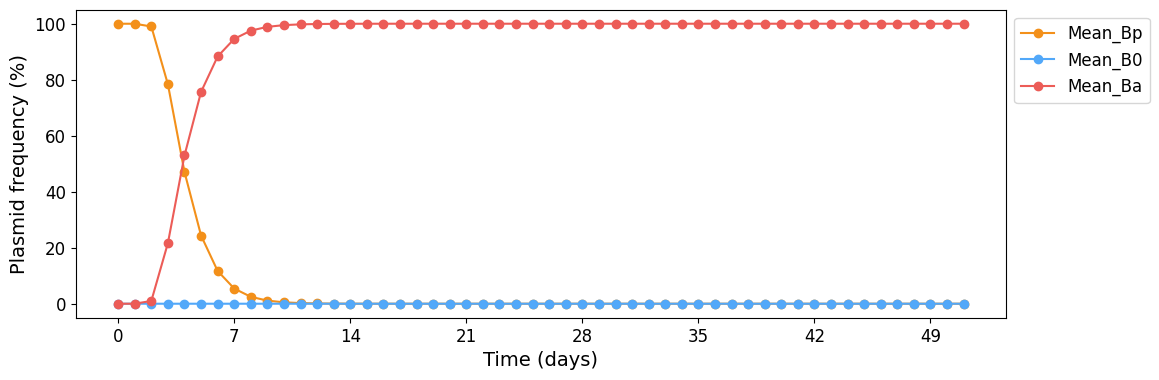

In [27]:
def plot_frequency_vs_time(result, T, model_params):
    """
    Plot the plasmid frequencies over time for multiple strains.

    Parameters
    ----------
    result : list of tuples
        Each tuple contains times and ys (simulation results) for a specific day.

    T : float
        Duration of each day in hours.

    model_params : dict
        Dictionary containing the strain labels and colors.

    Returns
    -------
    None
    """
    colors = model_params['colors']
    strain_labels = ["%s_%s" % (strain, type_) for strain, type_ in zip(model_params['strain'], model_params['type'])]

    plt.figure(figsize=(12, 4))
    num_strains = len(model_params['strain'])

    for istrain in range(num_strains):
        freqs = []
        times_days = []

        for day, (times, ys) in enumerate(result):
            color_strain = colors[istrain % len(colors)]

            # Calculate the frequency at the beginning of the first day
            if day == 0:
                total_population = sum(ys[2 + i, 0] for i in range(num_strains))
                frequency0 = 100 * ys[2 + istrain, 0] / total_population
                freqs.append(frequency0)
                times_days.append(day * T / 24)

            # Calculate the frequency at the end of each day
            total_population = sum(ys[2 + i, -1] for i in range(num_strains))
            frequency = 100 * ys[2 + istrain, -1] / total_population
            freqs.append(frequency)
            times_days.append((day + 1) * T / 24)

        plt.plot(times_days, freqs, '-o', color=color_strain, label=strain_labels[istrain])

    plt.xlabel('Time (days)', fontsize=14)
    plt.ylabel('Plasmid frequency (%)', fontsize=14)
    plt.xticks(np.arange(0, (len(result) + 1) * T / 24, 7), labels=np.arange(0, len(result) + 1, 7), fontsize=12)
    plt.ylim([-5, 105])
    plt.yticks(fontsize=12)
    plt.grid(False)
    plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()



plot_frequency_vs_time(result, model_params['T'], model_params)


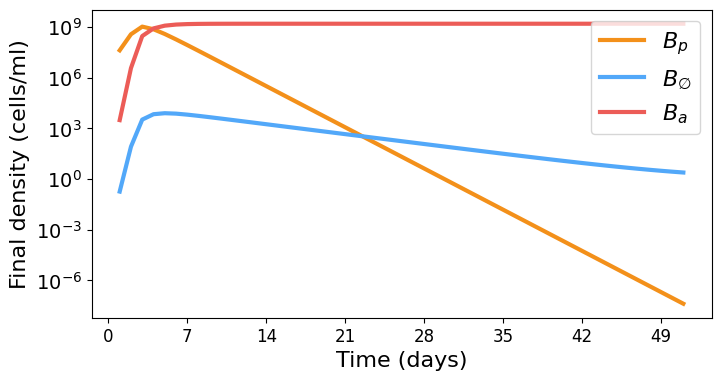

In [42]:
# Function to plot the density of each strain at the end of each day
def plot_B_end_of_day(result, T, model_params):
    colors = model_params['colors']
    strain_labels = ["%s" % (type_) for strain, type_ in zip(model_params['strain'], model_params['type'])]

    strain_labels = [label.replace('B0', r'$B_{\emptyset}$') for label in strain_labels]
    strain_labels = [label.replace('Ba', r'$B_{a}$') for label in strain_labels]
    strain_labels = [label.replace('Bp', r'$B_{p}$') for label in strain_labels]

    plt.figure(figsize=(8, 4))
    num_strains = len(result[0][1]) - 2  # Adjusted to match the number of strains
    for istrain in range(num_strains):
        end_day_times = []
        end_day_densities = []
        for day, (times, ys) in enumerate(result):
            # Only append the last time point and the corresponding density for each strain at the end of the day
            end_day_times.append((day + 1))  # End of the day time point
            end_day_densities.append(ys[2 + istrain, -1])  # Density at the end of the day

        color_strain = colors[istrain % len(colors)]
        plt.plot(end_day_times, end_day_densities, '-', color=color_strain, label=f'{strain_labels[istrain % len(strain_labels)]}', lw=3)

    plt.xlabel('Time (days)', fontsize=16)
    plt.ylabel('Final density (cells/ml)', fontsize=16)
    plt.yscale('log')
    plt.xticks(np.arange(0, len(result) + 1, 7), labels=np.arange(0, len(result) + 1, 7), fontsize=12)
    plt.legend(fontsize=16, loc='upper right')
    plt.yticks(fontsize=14)
    plt.grid(False)
    plt.show()

# Example usage
plot_B_end_of_day(result, model_params['T'], model_params)


In [30]:

def plot_resource_antibiotic_vs_time(result, T):
    plt.figure(figsize=(12, 4))
    for day, (times, ys) in enumerate(result):
        plt.plot(times + T * day, ys[0], '-', color='lime', label='Resource' if day == 0 else '')
        plt.plot(times + T * day, ys[1], '--', color='magenta', label='Antibiotic' if day == 0 else '')

    plt.xlabel('Time (days)', fontsize=14)
    plt.ylabel('Concentration', fontsize=14)
    plt.xticks(np.arange(0, len(result) * T + 1, T * 7), labels=np.arange(0, len(result) + 1, 7), fontsize=12)
    plt.legend(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(False)
    plt.show()

# Function to plot the total density of all strains over time
def plot_Btot_vs_time(result, T):

    plt.figure(figsize=(12, 4))

    for day, (times, ys) in enumerate(result):
        num_strains = int((len(ys) - 2))  # Adjusted to match the number of strains
        total_density = np.zeros_like(ys[0, :])

        for istrain in range(num_strains):
            total_density += ys[2 + istrain, :]

        plt.plot(times + T * day, total_density, '-', color='k')

    plt.xlabel('Time (days)', fontsize=14)
    plt.ylabel('Total Density', fontsize=14)
    plt.yscale('log')
    plt.xticks(np.arange(0, len(result) * T + 1, T * 7), labels=np.arange(0, len(result) + 1, 7), fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(False)
    plt.show()
def plot_BT_vs_time(result, T, model_params):
    """
    Plot the final densities of plasmid-bearing and plasmid-free strains over time.

    Parameters
    ----------
    result : list of tuples
        Each tuple contains times and ys (simulation results) for a specific day.

    T : float
        Duration of each day in hours.

    model_params : dict
        Dictionary containing the strain labels and colors.

    Returns
    -------
    None
    """
    colors = model_params['colors']
    strain_labels = ["%s_%s" % (strain, type_) for strain, type_ in zip(model_params['strain'], model_params['type'])]

    plt.figure(figsize=(12, 4))
    num_strains = len(result[0][1]) - 2  # Adjusted to match the number of strains
    ODT_time = []
    ODT_strain_free = []
    ODT_strain_bearing = []

    for day, (times, ys) in enumerate(result):
        if day == 0:
            ODT_time.append(0)
            ODT_strain_free.append(ys[2 + 1, 0])  # Plasmid-free
            ODT_strain_bearing.append(sum(ys[2 + i, 0] for i in range(num_strains) if model_params['type'][i] != 'B0'))  # Plasmid-bearing

        ODT_time.append(times[-1] + T * day)
        ODT_strain_free.append(ys[2 + 1, -1])  # Plasmid-free
        ODT_strain_bearing.append(sum(ys[2 + i, -1] for i in range(num_strains) if model_params['type'][i] != 'B0'))  # Plasmid-bearing

    plt.plot(ODT_time, ODT_strain_free, ':', color='k', label='Plasmid-free')
    plt.plot(ODT_time, ODT_strain_bearing, '-', color='k', label='Plasmid-bearing')

    plt.xlabel('Time (days)', fontsize=14)
    plt.ylabel('Final density', fontsize=14)
    plt.yscale('log')
    plt.xticks(np.arange(0, len(result) * T + 1, T * 7), labels=np.arange(0, len(result) + 1, 7), fontsize=12)
    plt.legend(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(False)
    plt.show()




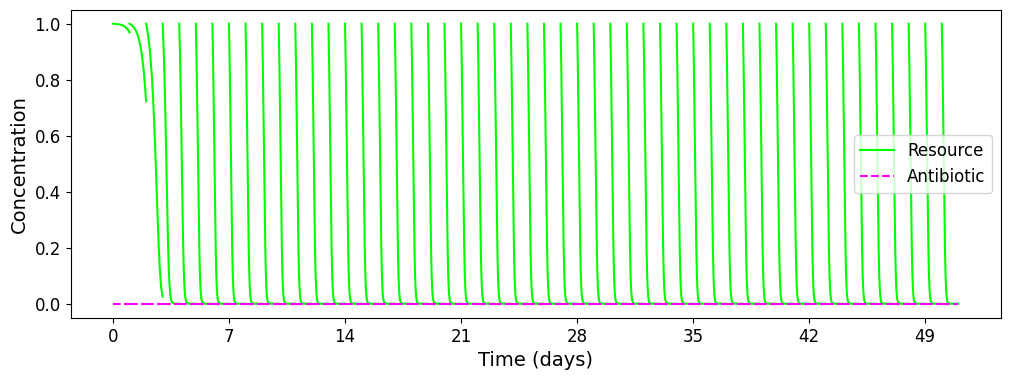

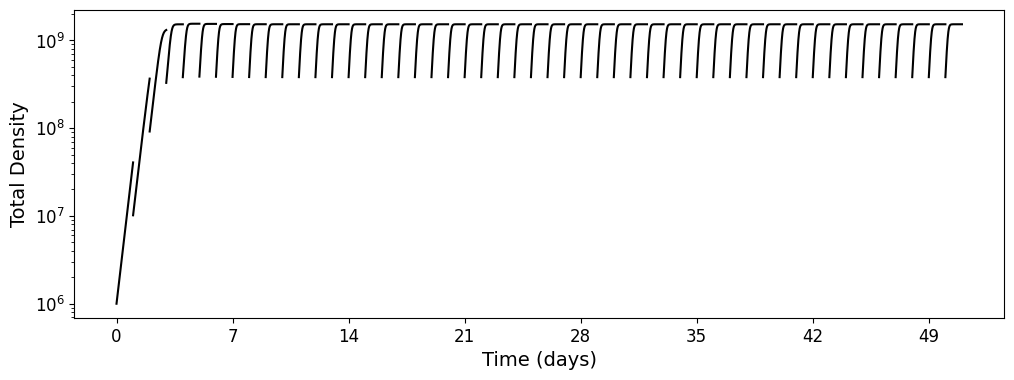

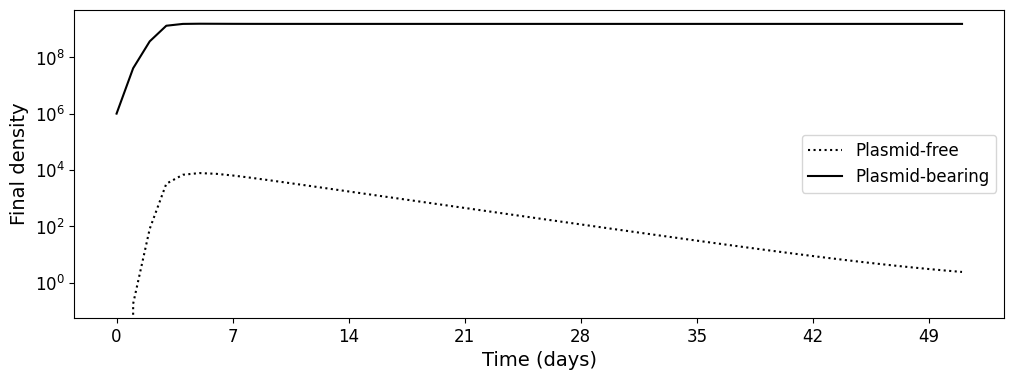

In [31]:

plot_resource_antibiotic_vs_time(result, model_params['T'])
plot_Btot_vs_time(result, model_params['T'])
plot_BT_vs_time(result, model_params['T'], model_params)

## With selective pressure


Initial conditions for day 0: [1.e+00 5.e+00 1.e+06 0.e+00 0.e+00]
..................................................

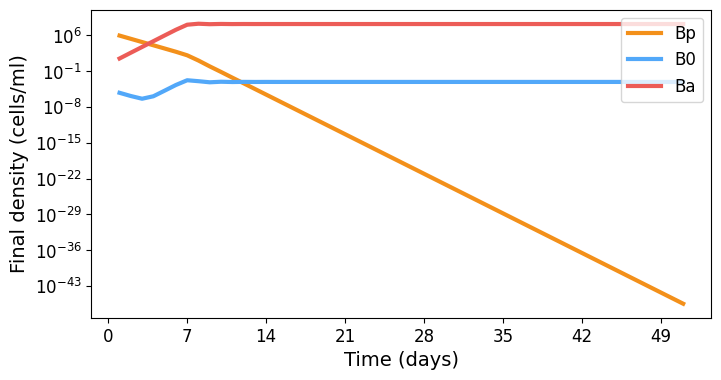

In [32]:
Amax=5
num_days=51


E = Amax*np.ones(num_days)

y0 = np.array([S0, Amax, B0 , 0, 0])
result_drug = runEvolutionaryExperiment(model_params, E, type_experiment, verbose=True)

plot_B_end_of_day(result_drug, model_params['T'], model_params)